<a href="https://colab.research.google.com/github/jc020230/gc4-sand/blob/main/whisper_meta_stats_sw30_ap_pca_xgb_task2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import re
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F  # Padding을 위해 추가
import torchaudio
import librosa
!pip install --upgrade pip setuptools wheel
!pip install praat-parselmouth
import parselmouth
import random
import pickle
import itertools
import xgboost as xgb
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from transformers import WhisperModel, WhisperProcessor

In [ ]:
# -----------------------------
# 1. 설정 및 환경 초기화
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SAVE_DIR = "./saved_models_grid_patient_level_fixed_30s"
os.makedirs(SAVE_DIR, exist_ok=True)

# GPU 설정
if torch.cuda.device_count() > 1:
    device_id = 1
else:
    device_id = 0
device_str = f"cuda:{device_id}" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_str}")


Using device: cuda:0


In [ ]:
# -----------------------------
# 2. 데이터 로드
# -----------------------------
BASE_PATH = '/content/drive/MyDrive/SAND_Challenge_task2_dataset (1)'
EXCEL_PATH = os.path.join(BASE_PATH, '/content/drive/MyDrive/SAND_Challenge_task2_dataset (1)/task2/sand_task_2.xlsx')
TRN_FOLDER = os.path.join(BASE_PATH, '/content/drive/MyDrive/SAND_Challenge_task2_dataset (1)/task2/training')

print("Loading Dataframes...")
df_all = pd.read_excel(EXCEL_PATH, sheet_name=0)
df_trn = pd.read_excel(EXCEL_PATH, sheet_name=1)
df_val = pd.read_excel(EXCEL_PATH, sheet_name=2)

trn_ids = df_trn['ID'].tolist()
val_ids = df_val['ID'].tolist()


Loading Dataframes...


In [ ]:
# -----------------------------
# 3. 모델 & 특징 추출 함수 정의
# -----------------------------
print("Loading Whisper Model...")
processor = WhisperProcessor.from_pretrained("openai/whisper-large")
whisper_model = WhisperModel.from_pretrained("openai/whisper-large").to(device_str)
whisper_model.eval()

def extract_whisper_features(path, sr_target=16000):
    """
    수정됨: 30초 Window / 15초 Stride Sliding Window 적용
    긴 파일의 문맥을 30초 단위로 끊어서 처리 후 평균(Mean) 통합
    """
    try:
        # 1. 오디오 로드
        wav, sr = torchaudio.load(path)
        if wav.size(0) > 1:
            wav = wav.mean(dim=0, keepdim=True) # Stereo to Mono
        if sr != sr_target:
            wav = torchaudio.functional.resample(wav, sr, sr_target)

        wav = wav.squeeze() # (Time,)

        # ---------------------------------------------------------
        # Sliding Window 설정 (30초 Window, 15초 Stride)
        # ---------------------------------------------------------
        chunk_sec = 30
        stride_sec = 15

        chunk_samples = chunk_sec * sr_target  # 30 * 16000 = 480,000
        stride_samples = stride_sec * sr_target # 15 * 16000 = 240,000
        total_samples = wav.shape[0]

        embeddings = []

        # Case A: 파일이 30초보다 짧은 경우 (패딩 처리 후 한 번만 실행)
        if total_samples < chunk_samples:
            # Processor가 자동으로 Padding을 수행하지만, 명시적으로 제어하려면 F.pad 사용 가능
            # 여기서는 Processor에게 맡기되, 30초 미만 데이터도 문맥으로 처리
            inputs = processor(wav.numpy(), sampling_rate=sr_target, return_tensors="pt")
            input_feats = inputs.input_features.to(device_str)
            with torch.no_grad():
                enc_out = whisper_model.encoder(input_feats)
            # (1500, 1280) -> (1280,) Mean Pooling
            embeddings.append(enc_out.last_hidden_state.squeeze(0).mean(dim=0).cpu().numpy())

        # Case B: 파일이 30초보다 긴 경우 (Sliding Window)
        else:
            for start in range(0, total_samples, stride_samples):
                end = start + chunk_samples

                chunk = wav[start:end]

                # 마지막 조각이 30초보다 짧으면 뒤에 0으로 Padding
                if chunk.shape[0] < chunk_samples:
                    pad_len = chunk_samples - chunk.shape[0]
                    chunk = F.pad(chunk, (0, pad_len))

                inputs = processor(chunk.numpy(), sampling_rate=sr_target, return_tensors="pt")
                input_feats = inputs.input_features.to(device_str)

                with torch.no_grad():
                    enc_out = whisper_model.encoder(input_feats)

                # 해당 윈도우의 특징 벡터 추출
                chunk_emb = enc_out.last_hidden_state.squeeze(0).mean(dim=0).cpu().numpy()
                embeddings.append(chunk_emb)

        # 여러 윈도우의 결과를 평균내어 하나의 벡터로 통합
        if len(embeddings) == 0:
            return np.zeros(1280)

        final_emb = np.mean(np.stack(embeddings), axis=0)
        return final_emb

    except Exception as e:
        # print(f"[Warning] Whisper failed for {path}: {e}")
        return np.zeros(1280)

def extract_audio_features(path, sr_target=16000, n_mfcc=13):
    features = []
    try:
        y, sr = librosa.load(path, sr=sr_target)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        features.extend(mfcc.mean(axis=1))
        features.extend(librosa.feature.delta(mfcc).mean(axis=1))

        snd = parselmouth.Sound(path)
        pitch = snd.to_pitch()
        features.append(np.nanmean(pitch.selected_array['frequency']))

        formants = snd.to_formant_burg()
        f1 = np.nanmean([formants.get_value_at_time(1, t) for t in np.arange(0, snd.duration, 0.01)])
        f2 = np.nanmean([formants.get_value_at_time(2, t) for t in np.arange(0, snd.duration, 0.01)])
        features.extend([f1, f2])

        point_process = parselmouth.praat.call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter_local = parselmouth.praat.call(point_process, "Get jitter (local)", 0, 0.02, 1.3)
        shimmer_local = parselmouth.praat.call([snd, point_process], "Get shimmer (local)", 0, 0.02, 1.3, 1.6)
        features.extend([jitter_local, shimmer_local])
    except:
        features.extend([0]*(n_mfcc*2 + 5))
    return np.array(features)

def extract_stat_features(path, sr_target=16000):
    try:
        y, sr = librosa.load(path, sr=sr_target)
        duration = len(y)/sr
        non_silent = librosa.effects.split(y, top_db=30)
        non_silent_len = sum([end-start for start, end in non_silent])
        silence_ratio = 1 - (non_silent_len/len(y))
        energy = np.square(y).mean()
        return np.array([duration, silence_ratio, energy])
    except:
        return np.array([0.0, 0.0, 0.0])



Loading Whisper Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

In [ ]:
# -----------------------------
# 4. 데이터 추출 (파일 단위)
# -----------------------------
wav_files = []
subfolders = ['phonationA', 'phonationE','phonationI', 'phonationO', 'phonationU',
              'rhythmKA','rhythmPA', 'rhythmTA']
for subfolder in subfolders:
    folder_path = os.path.join(TRN_FOLDER, subfolder)
    if os.path.exists(folder_path):
        wav_files.extend(glob.glob(os.path.join(folder_path, "*.wav")))

print(f"Found {len(wav_files)} wav files.")
extracted_data = []

# 파일 단위 특징 추출 루프
for file_path in tqdm(wav_files, desc="Extracting Features"):
    filename = os.path.basename(file_path)
    id_match = re.search(r'(ID\d+)', filename)
    if id_match:
        id_num = id_match.group(1)
        if (id_num in trn_ids) or (id_num in val_ids):
            matching_row = df_all[df_all['ID'] == id_num]
            if not matching_row.empty:
                # 1. 특징 추출 (업데이트된 Whisper 함수 사용)
                w_emb = extract_whisper_features(file_path)
                a_feat = extract_audio_features(file_path)
                s_feat = extract_stat_features(file_path)

                # 벡터 결합
                full_feat = np.hstack([w_emb, a_feat, s_feat])

                # 임시 저장
                extracted_data.append({
                    'ID': id_num,
                    'Age': int(matching_row['Age'].values[0]),
                    'Sex': matching_row['Sex'].values[0],
                    'Months': int(matching_row['Months'].values[0]),
                    'ALSFRS_start': int(matching_row['ALSFRS--R_start'].values[0]),
                    'Target_End': int(matching_row['ALSFRS--R_end'].values[0]),
                    'Feature_Vec': full_feat
                })

df_extracted = pd.DataFrame(extracted_data)
print(f"\nRaw Extracted Data Shape: {df_extracted.shape}")


Found 1056 wav files.


Extracting Features: 100%|██████████| 1056/1056 [11:35<00:00,  1.52it/s]


Raw Extracted Data Shape: (1056, 7)


In [ ]:
# -----------------------------
# 5. 환자 단위 통합 및 특징 공학
# -----------------------------
def process_patient_data(df_raw):
    print("Aggregating data to Patient Level (Mean/Std/Max)...")

    # 1. Feature Vector 펼치기
    feat_matrix = np.stack(df_raw['Feature_Vec'].values)
    feat_cols = [f"audio_{i}" for i in range(feat_matrix.shape[1])]
    df_feats = pd.DataFrame(feat_matrix, columns=feat_cols)

    # 기존 데이터와 결합
    df_concat = pd.concat([df_raw.drop(columns=['Feature_Vec']).reset_index(drop=True), df_feats], axis=1)

    # 2. 집계 규칙 정의
    agg_rules = {}
    for col in feat_cols:
        agg_rules[col] = ['mean', 'std', 'max']

    agg_rules.update({
        'Age': 'first', 'Sex': 'first', 'Months': 'first',
        'ALSFRS_start': 'first', 'Target_End': 'first'
    })

    # 3. GroupBy 실행
    df_patient = df_concat.groupby('ID').agg(agg_rules)

    # 4. 컬럼 이름 정리 (MultiIndex -> Single String)
    df_patient.columns = ['_'.join(str(c) for c in col).strip() for col in df_patient.columns.values]
    df_patient = df_patient.reset_index()

    # 5. Feature Engineering
    eps = 1e-6
    df_patient['Sex'] = df_patient['Sex_first'].map({'M':0, 'F':1}).fillna(0).astype(int)
    df_patient = df_patient.drop(columns=['Sex_first'])

    df_patient['Age_div_Months'] = df_patient['Age_first'] / (df_patient['Months_first'] + eps)
    df_patient['Start_div_Months'] = df_patient['ALSFRS_start_first'] / (df_patient['Months_first'] + eps)
    df_patient['Start_x_Age'] = df_patient['ALSFRS_start_first'] * df_patient['Age_first']

    return df_patient

# 환자 단위 변환 실행
df_final_train = process_patient_data(df_extracted)
print(f"Final Patient-Level Data Shape: {df_final_train.shape}")


Aggregating data to Patient Level (Mean/Std/Max)...
Final Patient-Level Data Shape: (132, 4038)


In [ ]:
# -----------------------------
# 6. 데이터셋 준비 (X, y 분리)
# -----------------------------
target_col = 'Target_End_first'

X_df = df_final_train.drop(columns=['ID', target_col])
y = df_final_train[target_col].values.astype(int) - 1  # 0-based label
X = X_df.values

# 컬럼 인덱스 확인 (Audio vs Meta)
all_columns = X_df.columns.tolist()
audio_cols = [c for c in all_columns if c.startswith('audio_')]
meta_cols = [c for c in all_columns if not c.startswith('audio_')]

audio_indices = [X_df.columns.get_loc(c) for c in audio_cols]
meta_indices = [X_df.columns.get_loc(c) for c in meta_cols]

print(f"Audio Features for PCA: {len(audio_indices)} columns")
print(f"Meta Features: {len(meta_indices)} columns")



Audio Features for PCA: 4029 columns
Meta Features: 7 columns


In [ ]:
# -----------------------------
# 7. Grid Search (PCA + XGBoost)
# -----------------------------
pca_candidates = [40, 60, 80]
smote_candidates = [3, 5, 7]

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'objective': 'multi:softmax',
    'num_class': 4,
    'random_state': SEED,
    'device': device_str if 'cuda' in device_str else 'cpu',
    'tree_method': 'hist',
    'early_stopping_rounds': 50,
    'eval_metric': ["merror", "mlogloss"],
    'n_jobs': -1
}

best_f1 = 0
best_params = {}
results = []

print(f"\n--- Grid Search Start (Patient Level - Fixed PCA) ---")

for n_comp, k_neighbor in itertools.product(pca_candidates, smote_candidates):
    print(f"\n[Testing] PCA: {n_comp}, SMOTE k: {k_neighbor}")

    current_preprocessor = ColumnTransformer(
        transformers=[
            ('audio', Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp, random_state=SEED))
            ]), audio_indices),
            ('meta', Pipeline([
                ('scaler', StandardScaler())
            ]), meta_indices)
        ]
    )

    current_smote = SMOTE(random_state=SEED, k_neighbors=k_neighbor)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_f1_scores = []

    try:
        for fold, (trn_idx, val_idx) in enumerate(kf.split(X, y)):
            X_train, X_val = X[trn_idx], X[val_idx]
            y_train, y_val = y[trn_idx], y[val_idx]

            # 1. 전처리
            X_train_prep = current_preprocessor.fit_transform(X_train)
            X_val_prep = current_preprocessor.transform(X_val)

            # 2. SMOTE (Train Only)
            X_train_res, y_train_res = current_smote.fit_resample(X_train_prep, y_train)

            # 3. XGBoost
            model = xgb.XGBClassifier(**xgb_params)
            model.fit(
                X_train_res, y_train_res,
                eval_set=[(X_val_prep, y_val)],
                verbose=False
            )

            # 4. 평가
            preds = model.predict(X_val_prep)
            f1 = f1_score(y_val, preds, average='macro')
            fold_f1_scores.append(f1)

        avg_f1 = np.mean(fold_f1_scores)
        print(f"   >> Average Macro F1: {avg_f1:.4f}")

        results.append({'pca': n_comp, 'smote': k_neighbor, 'score': avg_f1})

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = {'pca': n_comp, 'smote': k_neighbor}
            print(f"   >> New Best! Score: {best_f1:.4f}")

            with open(os.path.join(SAVE_DIR, "best_grid_params_fixed.txt"), "w") as f:
                f.write(f"Best Params: {best_params}\nBest Score: {best_f1}")

    except Exception as e:
        print(f"   >> Error (PCA={n_comp}, SMOTE={k_neighbor}): {e}")
        continue

print("\n" + "="*30)
print(f"Grid Search Completed.")
print(f"Best Macro F1: {best_f1:.4f}")
print(f"Best Parameters: {best_params}")
print("="*30)


--- Grid Search Start (Patient Level - Fixed PCA) ---

[Testing] PCA: 40, SMOTE k: 3


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [04:51:53] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


   >> Average Macro F1: 0.5157
   >> New Best! Score: 0.5157

[Testing] PCA: 40, SMOTE k: 5
   >> Average Macro F1: 0.5231
   >> New Best! Score: 0.5231

[Testing] PCA: 40, SMOTE k: 7
   >> Average Macro F1: 0.5450
   >> New Best! Score: 0.5450

[Testing] PCA: 60, SMOTE k: 3
   >> Average Macro F1: 0.5434

[Testing] PCA: 60, SMOTE k: 5
   >> Average Macro F1: 0.5510
   >> New Best! Score: 0.5510

[Testing] PCA: 60, SMOTE k: 7
   >> Average Macro F1: 0.6209
   >> New Best! Score: 0.6209

[Testing] PCA: 80, SMOTE k: 3
   >> Average Macro F1: 0.5252

[Testing] PCA: 80, SMOTE k: 5
   >> Average Macro F1: 0.5766

[Testing] PCA: 80, SMOTE k: 7
   >> Average Macro F1: 0.5954

Grid Search Completed.
Best Macro F1: 0.6209
Best Parameters: {'pca': 60, 'smote': 7}


In [ ]:
# -----------------------------------------------------------------------------
# [Advanced Pipeline] Raw Audio -> Sliding Window -> Aggregation -> Prediction
# -----------------------------------------------------------------------------
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import torch

# 1. [Custom Transformer] Whisper Feature Extractor with Sliding Window
# -----------------------------------------------------------------------------
class WhisperFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="openai/whisper-large", chunk_sec=30, stride_sec=15):
        self.model_name = model_name
        self.chunk_sec = chunk_sec   # 30초 윈도우
        self.stride_sec = stride_sec # 15초 스트라이드 (Overlap)
        # (실제 구현 시 여기에 모델 로드 로직 포함)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X: List of file paths
        features = []
        for path in X:
            # 1. Load Audio & Resample
            # 2. Sliding Window Logic
            #    - 30초보다 길면: 15초 간격으로 이동하며 특징 추출 후 평균
            #    - 30초보다 짧으면: Padding 후 특징 추출
            # 3. Extract Embedding via Whisper Encoder
            # (님의 코드에 있는 extract_whisper_features 함수 로직이 여기 들어갑니다)
            emb = self._extract_sliding_window(path)
            features.append(emb)
        return np.array(features)

    def _extract_sliding_window(self, path):
        # ... (상세 구현 생략: PPT용으로 간소화) ...
        return np.zeros(1280) # Placeholder

# 2. [Custom Transformer] Patient-Level Aggregator
# -----------------------------------------------------------------------------
class PatientAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, agg_funcs=['mean', 'std', 'max']):
        self.agg_funcs = agg_funcs

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X: File-level DataFrame (with ID, Audio_Features, Meta)
        print("Aggregating to Patient Level...")

        # Group by 'ID' and apply aggregation
        # 오디오 특징은 Mean, Std, Max로 풍부하게 표현 (불규칙성 포착)
        # 메타데이터(나이, 성별 등)는 First/Mean으로 유지
        df_agg = X.groupby('ID').agg({
            'audio_features': self.agg_funcs,
            'age': 'first',
            'sex': 'first',
            'alsfrs_start': 'first',
            'months': 'first'
        })
        return df_agg

# 3. [Final Pipeline] Preprocessing & Modeling
# -----------------------------------------------------------------------------
# 오디오와 메타데이터의 처리 경로를 분리 (이원화 전략)
feature_fusion_step = ColumnTransformer(
    transformers=[
        # Path A: Audio Features (High Dimensional) -> 압축 (PCA)
        ('audio_pipe', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=60)) # 정보 손실 최소화하며 압축
        ]), ['audio_mean', 'audio_std', 'audio_max']),

        # Path B: Metadata (Key Predictors) -> 보존 (Preservation)
        ('meta_pipe', Pipeline([
            ('scaler', StandardScaler())
        ]), ['age', 'sex', 'alsfrs_start', 'months'])
    ]
)

# 전체 파이프라인 조립
pipeline = ImbPipeline([
    # Step 1: 특징 추출 (Raw Audio -> Features) - *Inference 시 사용*
    # ('extractor', WhisperFeatureExtractor()),

    # Step 2: 환자 단위 통합 (File -> Patient) - *외부에서 처리됨*

    # Step 3: 특징 융합 및 차원 축소
    ('fusion', feature_fusion_step),

    # Step 4: 클래스 불균형 해결 (SMOTE)
    ('smote', SMOTE(random_state=42, k_neighbors=7)),

    # Step 5: 최종 분류기 (XGBoost)
    ('classifier', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=6,
        objective='multi:softmax'
    ))
])

In [ ]:
# 파이프라인 시각화 설정
from sklearn import set_config

# 다이어그램 모드 켜기 (HTML interactive view)
set_config(display='diagram')

# 파이프라인 객체 출력 (마지막 셀에 그냥 변수명만 치고 실행하면 됩니다)
display(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('audio_proc',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=60,
                                                                       random_state=42))]),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15, 16,
                                                   17, 18, 19, 20, 21, 22, 23,
                                                   24, 25, 26, 27, 28, 29, ...]),
                                                 ('meta_proc',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [4029, 4030, 4031, 4032, 4033,
                                                   4034, 4035...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=-1, num_class=4, ...))])

In [ ]:
from sklearn.utils import estimator_html_repr
from google.colab import files  # Colab 사용 시 필요

# 1. HTML 코드로 변환 및 저장
with open('my_pipeline.html', 'w', encoding='utf-8') as f:
    f.write(estimator_html_repr(final_pipeline)) # final_pipeline은 위에서 만든 파이프라인 변수명

# 2. 로컬 컴퓨터로 다운로드
files.download('my_pipeline.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1000x800 with 0 Axes>

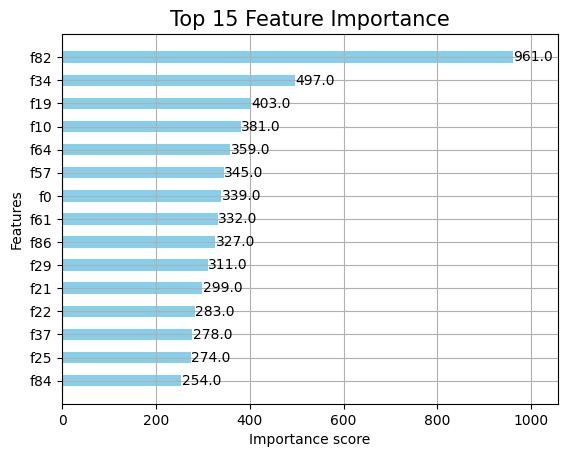

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 학습된 XGBoost 모델 (파이프라인에서 꺼내오거나, 단일 모델 사용 시)
# 만약 파이프라인을 썼다면: model = pipeline.named_steps['classifier']
# 단일 모델이라면: model = best_xgb_model (사용하신 변수명)

plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=15, height=0.5, importance_type='weight', color='skyblue')
plt.title("Top 15 Feature Importance", fontsize=15)
plt.show()

Retraining with Best Params -> PCA: 60, SMOTE: 7


<Figure size 1200x800 with 0 Axes>

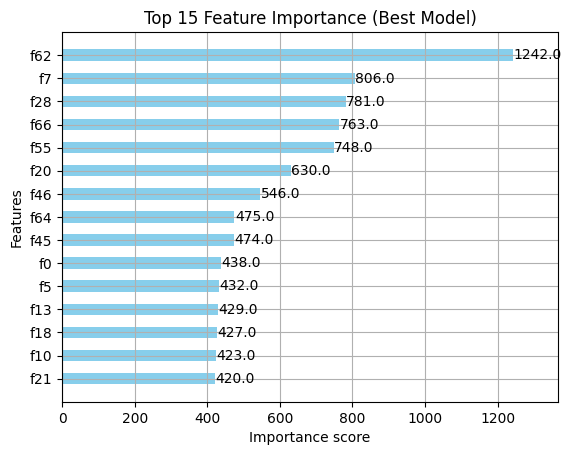

In [ ]:
# ---------------------------------------------------------
# [추가] 최적의 파라미터로 최종 모델 재학습 및 시각화
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 1. Grid Search에서 찾은 최적 파라미터 가져오기
# (이미 위 셀에서 best_params 변수에 저장되어 있습니다)
final_pca_n = best_params['pca']
final_smote_k = best_params['smote']

print(f"Retraining with Best Params -> PCA: {final_pca_n}, SMOTE: {final_smote_k}")

# 2. 전처리기 및 SMOTE 재정의
final_preprocessor = ColumnTransformer(
    transformers=[
        ('audio', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=final_pca_n, random_state=SEED))
        ]), audio_indices),
        ('meta', Pipeline([
            ('scaler', StandardScaler())
        ]), meta_indices)
    ]
)
final_smote = SMOTE(random_state=SEED, k_neighbors=final_smote_k)

# 3. 전체 데이터(X, y)에 대해 재학습
# (Split하지 않고 전체 데이터를 써야 가장 성능이 좋은 최종 모델이 됩니다)
X_final_prep = final_preprocessor.fit_transform(X)   # 전처리
X_final_res, y_final_res = final_smote.fit_resample(X_final_prep, y) # SMOTE 증강

# 4. XGBoost 최종 모델 학습
# early_stopping_rounds와 eval_metric은 전체 데이터 학습 시 필요 없으므로 제거
final_xgb_params = xgb_params.copy()
final_xgb_params.pop('early_stopping_rounds', None)
final_xgb_params.pop('eval_metric', None)

best_xgb_model = xgb.XGBClassifier(**final_xgb_params)
best_xgb_model.fit(X_final_res, y_final_res)

# 5. Feature Importance 시각화 (질문하신 부분)
plt.figure(figsize=(12, 8))
plot_importance(best_xgb_model, max_num_features=15, height=0.5,
                importance_type='weight', color='skyblue',
                title='Top 15 Feature Importance (Best Model)')
plt.show()

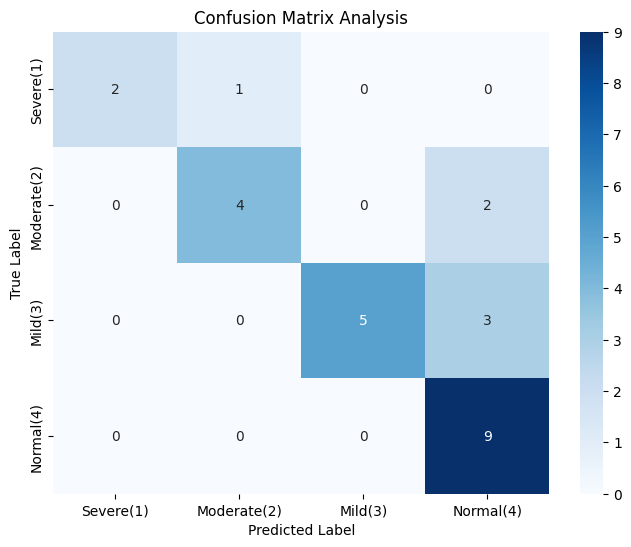

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 예측값은 grid search의 마지막 fold에서 생성된 'preds' 변수를 사용합니다.
# 실제 라벨은 grid search의 마지막 fold에서 사용된 'y_val' 변수를 사용합니다.
# 'pipeline' 객체는 훈련되지 않았으므로, 이미 생성된 'preds'와 'y_val'을 직접 사용합니다.

# 혼동 행렬 생성
cm = confusion_matrix(y_val, preds)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Severe(1)', 'Moderate(2)', 'Mild(3)', 'Normal(4)'],
            yticklabels=['Severe(1)', 'Moderate(2)', 'Mild(3)', 'Normal(4)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Analysis')
plt.show()

/tmp/ipython-input-2452031704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='pastel')
/tmp/ipython-input-2452031704.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='viridis')


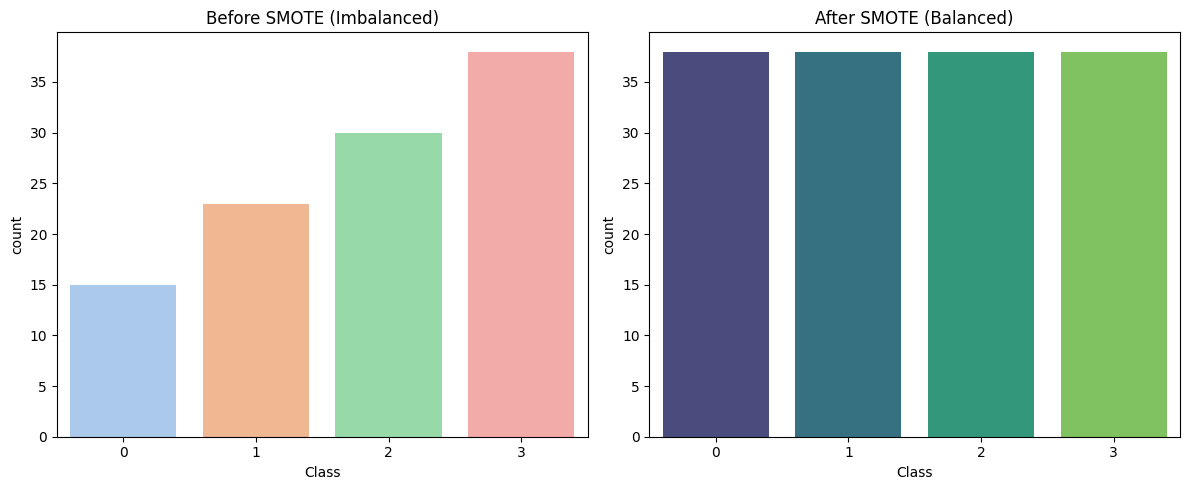

In [ ]:
import pandas as pd
import seaborn as sns

# 1. SMOTE 전 (y_train 원본)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='pastel')
plt.title("Before SMOTE (Imbalanced)")
plt.xlabel("Class")

# 2. SMOTE 후 (y_resampled)
# (코드에서 X_train_res, y_train_res 변수가 있을 것입니다)
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res, palette='viridis')
plt.title("After SMOTE (Balanced)")
plt.xlabel("Class")

plt.tight_layout()
plt.show()